# **SmartCropCare: Image-based Plant Disease Classification with CNNs**




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

zip_path = '/content/drive/MyDrive/cnnProject.zip'

In [3]:
# Path where the files will be extracted
extract_path = '/tmp/cnn_project/'

print(f"Extraction target: {extract_path}")

Extraction target: /tmp/cnn_project/


In [4]:
#  the unzip command
!unzip -q $zip_path -d $extract_path
print(f"Files extracted to: {extract_path}")

Files extracted to: /tmp/cnn_project/


In [5]:
# list the contents
!ls /tmp/cnn_project/

'new plant diseases dataset(augmented)'   test
'New Plant Diseases Dataset(Augmented)'


# Step 1: **Import Required Libraries**

In [6]:
# importing libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

# Step 2: **Define Paths**

In [7]:
# Base dataset path
base_dir = '/tmp/cnn_project/New Plant Diseases Dataset/'

# Train and validation directories
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')

print("Train directory:", train_dir)
print("Validation directory:", valid_dir)

Train directory: /tmp/cnn_project/New Plant Diseases Dataset/train
Validation directory: /tmp/cnn_project/New Plant Diseases Dataset/valid


# **Step 3: Image Preprocessing and Augmentation**

In [8]:
# For training data (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixel values
    rotation_range=20,           # rotate images randomly
    width_shift_range=0.2,       # horizontal shift
    height_shift_range=0.2,      # vertical shift
    shear_range=0.2,             # shear angle
    zoom_range=0.2,              # zoom randomly
    horizontal_flip=True,        # flip images
    fill_mode='nearest',         # fill empty pixels
    validation_split=0.2         # reserve 20% for validation
)

# For validation data (only rescaling)
valid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Step 4: **Create Data Generators**

In [9]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64

# Define augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixels
    rotation_range=20,           # random rotation
    width_shift_range=0.2,       # horizontal shift
    height_shift_range=0.2,      # vertical shift
    shear_range=0.2,             # shear
    zoom_range=0.2,              # zoom in/out
    horizontal_flip=True,        # flip horizontally
    fill_mode='nearest'          # fill missing pixels
)

# Validation data only needs rescaling
valid_datagen = ImageDataGenerator(rescale=1./255)

print("Data generators (ImageDataGenerator) initialized successfully.")


Data generators (ImageDataGenerator) initialized successfully.


# Fix dataset split..Recreate Keras generators

In [10]:

import os, random, shutil
from pathlib import Path
from math import ceil

random.seed(123)

# Base search path
BASE_SEARCH = Path("/tmp/cnn_project")

# Find the dataset root

def find_dataset_roots(base, min_classes=5, min_files_per_class=5, max_depth=3):
    candidates = []
    for root, dirs, files in os.walk(base):
        depth = len(Path(root).relative_to(base).parts)
        if depth > max_depth:
            continue
        subdirs = [os.path.join(root,d) for d in dirs]
        count_classes = 0
        for sd in subdirs:
            try:
                files_in_sd = [f for f in os.listdir(sd) if os.path.isfile(os.path.join(sd,f))]
                if len(files_in_sd) >= min_files_per_class:
                    count_classes += 1
            except Exception:
                pass
        if count_classes >= min_classes:
            candidates.append((root, count_classes))
    candidates.sort(key=lambda x: -x[1])
    return candidates

print("Searching for dataset candidate roots under", BASE_SEARCH, "...")
cands = find_dataset_roots(BASE_SEARCH, min_classes=8, min_files_per_class=10, max_depth=4)
if not cands:
    print(" No valid dataset roots found. Please check folder structure manually using '!ls -la /tmp/cnn_project'")
else:
    print("Found candidate dataset roots (top 5):")
    for i, (root, ncls) in enumerate(cands[:5], 1):
        print(f"{i}. {root} (approx. {ncls} class folders)")

    src_root = Path(cands[0][0])
    print("\n Using dataset root:", src_root)

    # Create split folders
    out_root = Path("/tmp/cnn_project/split_dataset")
    train_out = out_root / "train"
    val_out   = out_root / "val"
    test_out  = out_root / "test"

    def folder_has_images(p):
        if not p.exists(): return False
        for cls in p.iterdir():
            if cls.is_dir():
                if any(cls.glob("*")):
                    return True
        return False

    if folder_has_images(train_out) and folder_has_images(val_out) and folder_has_images(test_out):
        print("Clean split already exists at:", out_root)
    else:
        print(" Creating new clean split...")
        for d in (train_out, val_out, test_out):
            d.mkdir(parents=True, exist_ok=True)
        test_frac = 0.20
        val_frac = 0.10
        for cls_dir in sorted([p for p in src_root.iterdir() if p.is_dir()]):
            files = sorted([f for f in cls_dir.iterdir() if f.is_file()])
            if len(files) == 0:
                continue
            random.shuffle(files)
            n_test = max(1, int(len(files) * test_frac))
            n_val = max(1, int(len(files) * val_frac))
            test_files = files[:n_test]
            val_files = files[n_test:n_test+n_val]
            train_files = files[n_test+n_val:]

            (train_out/cls_dir.name).mkdir(parents=True, exist_ok=True)
            (val_out/cls_dir.name).mkdir(parents=True, exist_ok=True)
            (test_out/cls_dir.name).mkdir(parents=True, exist_ok=True)

            for f in train_files:
                dst = train_out/cls_dir.name / f.name
                if not dst.exists():
                    try: os.symlink(f.resolve(), dst)
                    except Exception: shutil.copy(f, dst)
            for f in val_files:
                dst = val_out/cls_dir.name / f.name
                if not dst.exists():
                    try: os.symlink(f.resolve(), dst)
                    except Exception: shutil.copy(f, dst)
            for f in test_files:
                dst = test_out/cls_dir.name / f.name
                if not dst.exists():
                    try: os.symlink(f.resolve(), dst)
                    except Exception: shutil.copy(f, dst)
        print("Split created successfully at:", out_root)
    train_generator = train_datagen.flow_from_directory(
        str(train_out),
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=123
    )
    valid_generator = valid_datagen.flow_from_directory(
        str(val_out),
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    test_generator = valid_datagen.flow_from_directory(
        str(test_out),
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    print("\n Dataset Summary")
    print("Train samples:", train_generator.samples, "Classes:", train_generator.num_classes)
    print("Validation samples:", valid_generator.samples)
    print("Test samples:", test_generator.samples)
    print("Steps per epoch:", max(1, ceil(train_generator.samples / BATCH_SIZE)))


Searching for dataset candidate roots under /tmp/cnn_project ...
Found candidate dataset roots (top 5):
1. /tmp/cnn_project/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid (approx. 38 class folders)
2. /tmp/cnn_project/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train (approx. 38 class folders)
3. /tmp/cnn_project/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid (approx. 38 class folders)
4. /tmp/cnn_project/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train (approx. 38 class folders)

 Using dataset root: /tmp/cnn_project/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
 Creating new clean split...
Split created successfully at: /tmp/cnn_project/split_dataset
Found 12327 images belonging to 38 classes.
Found 1742 images belonging to 38 classes.
Found 3503 images belonging to 38 classes.

 Dataset Summary
Train samples: 12327

# **Step 5: Build CNN Model**

In [11]:
num_classes = train_generator.num_classes

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout

inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = Conv2D(32,(3,3),padding='same',activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)
x = Conv2D(64,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)
x = Conv2D(128,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


# **Step 6: Compile the Model**

In [12]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [13]:
#  Define training callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
ckpt = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# **Step 7: Train the Model**

In [15]:
from math import ceil

EPOCHS = 20
steps_per_epoch = ceil(train_generator.samples / BATCH_SIZE)
validation_steps = ceil(valid_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=[early, reduce_lr, ckpt]
)


Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4384 - loss: 2.0612
Epoch 1: val_loss improved from 3.78241 to 2.06848, saving model to best_model.h5


193/193 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.4385 - loss: 2.0608 - val_accuracy: 0.4191 - val_loss: 2.0685 - learning_rate: 1.0000e-04
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5024 - loss: 1.7814
Epoch 2: val_loss improved from 2.06848 to 1.67029, saving model to best_model.h5


193/193 ━━━━━━━━━━━━━━━━━━━━ 552s 3s/step - accuracy: 0.5025 - loss: 1.7812 - val_accuracy: 0.5505 - val_loss: 1.6703 - learning_rate: 1.0000e-04
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5349 - loss: 1.6293
Epoch 3: val_loss did not improve from 1.67029
193/193 ━━━━━━━━━━━━━━━━━━━━ 564s 3s/step - accuracy: 0.5349 - loss: 1.6291 - val_accuracy: 0.5011 - val_loss: 1.6939 - learning_rate: 1.0000e-04
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5733 - loss: 1.4799
Epoch 4: val_loss did not improve from 1.67029
193/193 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.5733 - loss: 1.4798 - val_accuracy: 0.4943 - val_loss: 1.7006 - learning_rate: 1.0000e-04
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6042 - loss: 1.3739
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 5: val_loss did not improve from 1.67029
193/193 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.6042 - loss: 1.3738 - val_accurac

193/193 ━━━━━━━━━━━━━━━━━━━━ 552s 3s/step - accuracy: 0.6245 - loss: 1.2968 - val_accuracy: 0.5459 - val_loss: 1.5993 - learning_rate: 5.0000e-05
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6477 - loss: 1.2144
Epoch 7: val_loss did not improve from 1.59931
193/193 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.6477 - loss: 1.2144 - val_accuracy: 0.5080 - val_loss: 1.7012 - learning_rate: 5.0000e-05
Epoch 8/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6463 - loss: 1.1858
Epoch 8: val_loss improved from 1.59931 to 1.50821, saving model to best_model.h5


193/193 ━━━━━━━━━━━━━━━━━━━━ 535s 3s/step - accuracy: 0.6463 - loss: 1.1857 - val_accuracy: 0.5649 - val_loss: 1.5082 - learning_rate: 5.0000e-05
Epoch 9/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6753 - loss: 1.1316
Epoch 9: val_loss did not improve from 1.50821
193/193 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.6753 - loss: 1.1316 - val_accuracy: 0.5672 - val_loss: 1.5422 - learning_rate: 5.0000e-05
Epoch 10/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6816 - loss: 1.1032
Epoch 10: val_loss did not improve from 1.50821
193/193 ━━━━━━━━━━━━━━━━━━━━ 563s 3s/step - accuracy: 0.6816 - loss: 1.1032 - val_accuracy: 0.5580 - val_loss: 1.5681 - learning_rate: 5.0000e-05
Epoch 11/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6911 - loss: 1.0572
Epoch 11: val_loss improved from 1.50821 to 1.48318, saving model to best_model.h5


193/193 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.6911 - loss: 1.0573 - val_accuracy: 0.5695 - val_loss: 1.4832 - learning_rate: 5.0000e-05
Epoch 12/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7015 - loss: 1.0249
Epoch 12: val_loss did not improve from 1.48318
193/193 ━━━━━━━━━━━━━━━━━━━━ 567s 3s/step - accuracy: 0.7015 - loss: 1.0249 - val_accuracy: 0.5270 - val_loss: 1.6536 - learning_rate: 5.0000e-05
Epoch 13/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7063 - loss: 1.0222
Epoch 13: val_loss did not improve from 1.48318
193/193 ━━━━━━━━━━━━━━━━━━━━ 551s 3s/step - accuracy: 0.7063 - loss: 1.0221 - val_accuracy: 0.5362 - val_loss: 1.6545 - learning_rate: 5.0000e-05
Epoch 14/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7210 - loss: 0.9734
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 14: val_loss did not improve from 1.48318
193/193 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.7210 - loss: 0.9734 - val_

193/193 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.7293 - loss: 0.9438 - val_accuracy: 0.6045 - val_loss: 1.3693 - learning_rate: 2.5000e-05
Epoch 16/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7202 - loss: 0.9475
Epoch 16: val_loss did not improve from 1.36928
193/193 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.7202 - loss: 0.9474 - val_accuracy: 0.5867 - val_loss: 1.4277 - learning_rate: 2.5000e-05
Epoch 17/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7370 - loss: 0.9236
Epoch 17: val_loss did not improve from 1.36928
193/193 ━━━━━━━━━━━━━━━━━━━━ 549s 3s/step - accuracy: 0.7370 - loss: 0.9236 - val_accuracy: 0.5993 - val_loss: 1.4211 - learning_rate: 2.5000e-05
Epoch 18/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7350 - loss: 0.9085
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 18: val_loss did not improve from 1.36928
193/193 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.7350 - loss: 0.9085 - val_

# Step 8: **Plot Training and Validation Graphs**

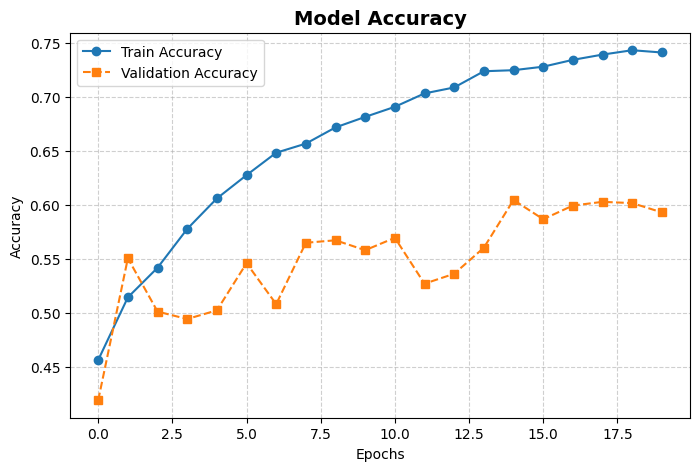

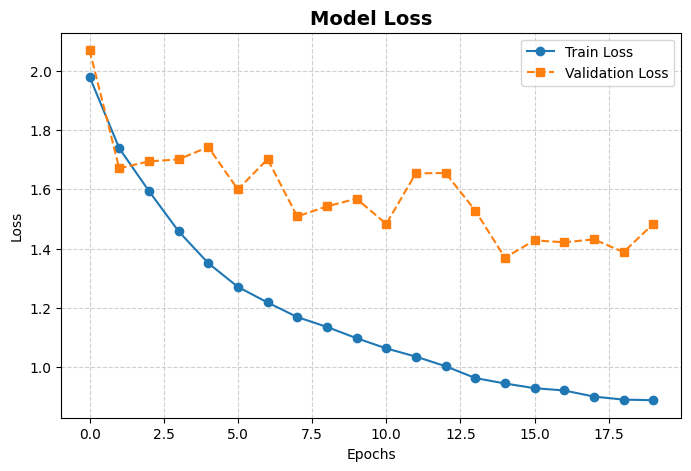

In [21]:
# Acuracy
plt.figure(figsize=(8,5))
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], marker='o', linestyle='-', label='Train Accuracy')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], marker='s', linestyle='--', label='Validation Accuracy')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
# Loss
plt.figure(figsize=(8,5))
if 'loss' in history.history:
    plt.plot(history.history['loss'], marker='o', linestyle='-', label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='s', linestyle='--', label='Validation Loss')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Step 9: Create Test Generator

In [30]:
from math import ceil
import numpy as np
from sklearn.metrics import classification_report

test_dir = "/tmp/cnn_project/split_dataset/test"

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 3503 images belonging to 38 classes.


# Step 10: **Evaluate on Test Set**

In [32]:
test_steps = ceil(test_generator.samples / test_generator.batch_size)
results = model.evaluate(test_generator, steps=test_steps, verbose=1)
print(f"\n Final Test Loss: {results[0]:.4f}")
print(f"Final Test Accuracy: {results[1]*100:.2f}%")


55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 509ms/step - accuracy: 0.0541 - loss: 3.6321

 Final Test Loss: 3.6349
Final Test Accuracy: 2.65%


# Step 11: **Classification Report & Confusion Matrix**

In [33]:
Y_pred = model.predict(test_generator, steps=test_steps, verbose=1)
if Y_pred.shape[0] > test_generator.samples:
    Y_pred = Y_pred[:test_generator.samples]
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.array(test_generator.classes)[:len(y_pred)]

class_labels = [k for k,v in sorted(test_generator.class_indices.items(), key=lambda x: x[1])]

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))


55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 507ms/step

--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.00      0.00      0.00       100
                                 Apple___Black_rot       0.00      0.00      0.00        99
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        88
                                   Apple___healthy       0.00      0.00      0.00       100
                               Blueberry___healthy       0.03      0.97      0.06        90
          Cherry_(including_sour)___Powdery_mildew       0.00      0.00      0.00        84
                 Cherry_(including_sour)___healthy       0.00      0.00      0.00        91
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.01      0.07      0.02        82
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00        95
      

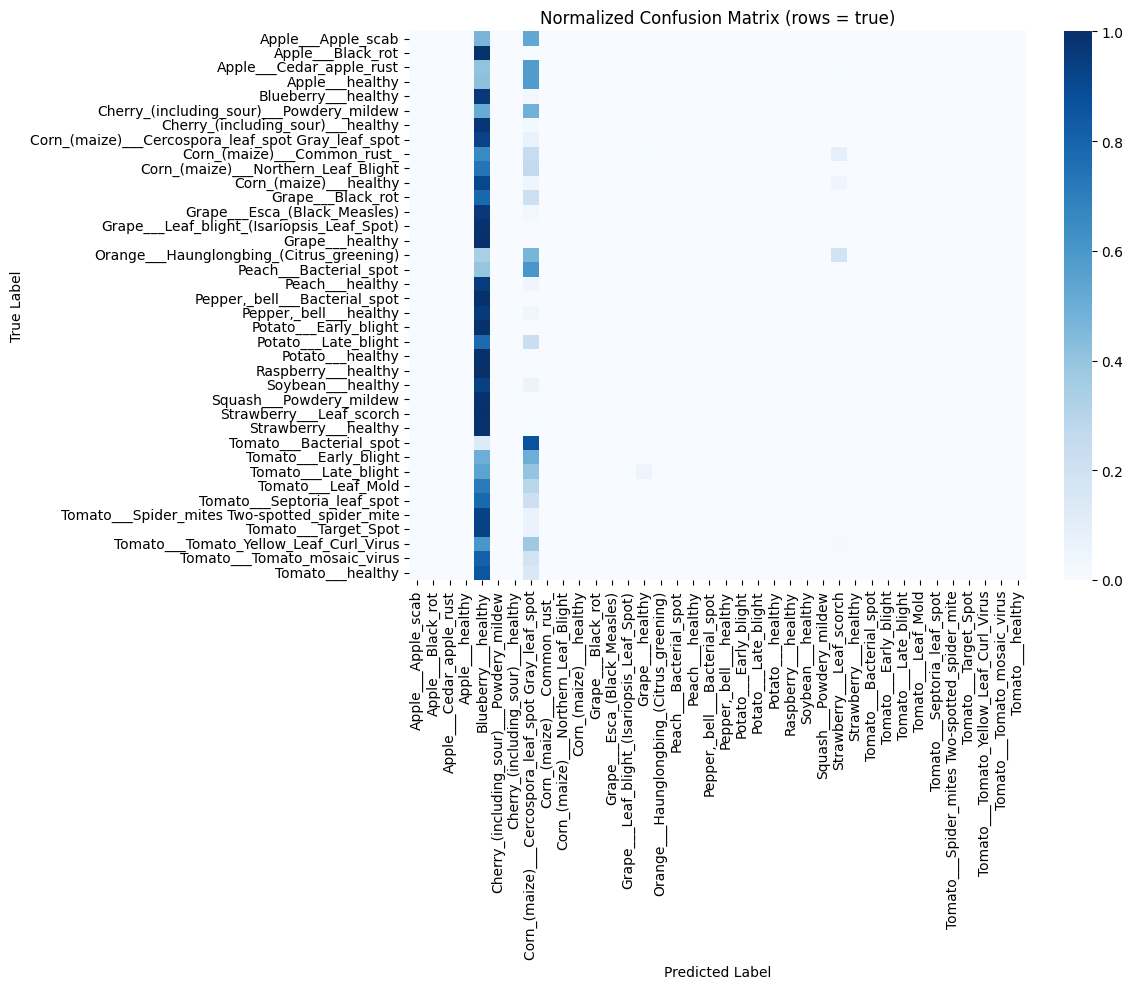

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Normalized Confusion Matrix (rows = true)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Step 12: **Visualize Misclassified Images (Error Analysis)**

Total Misclassified Images: 3410 — displaying first 10.


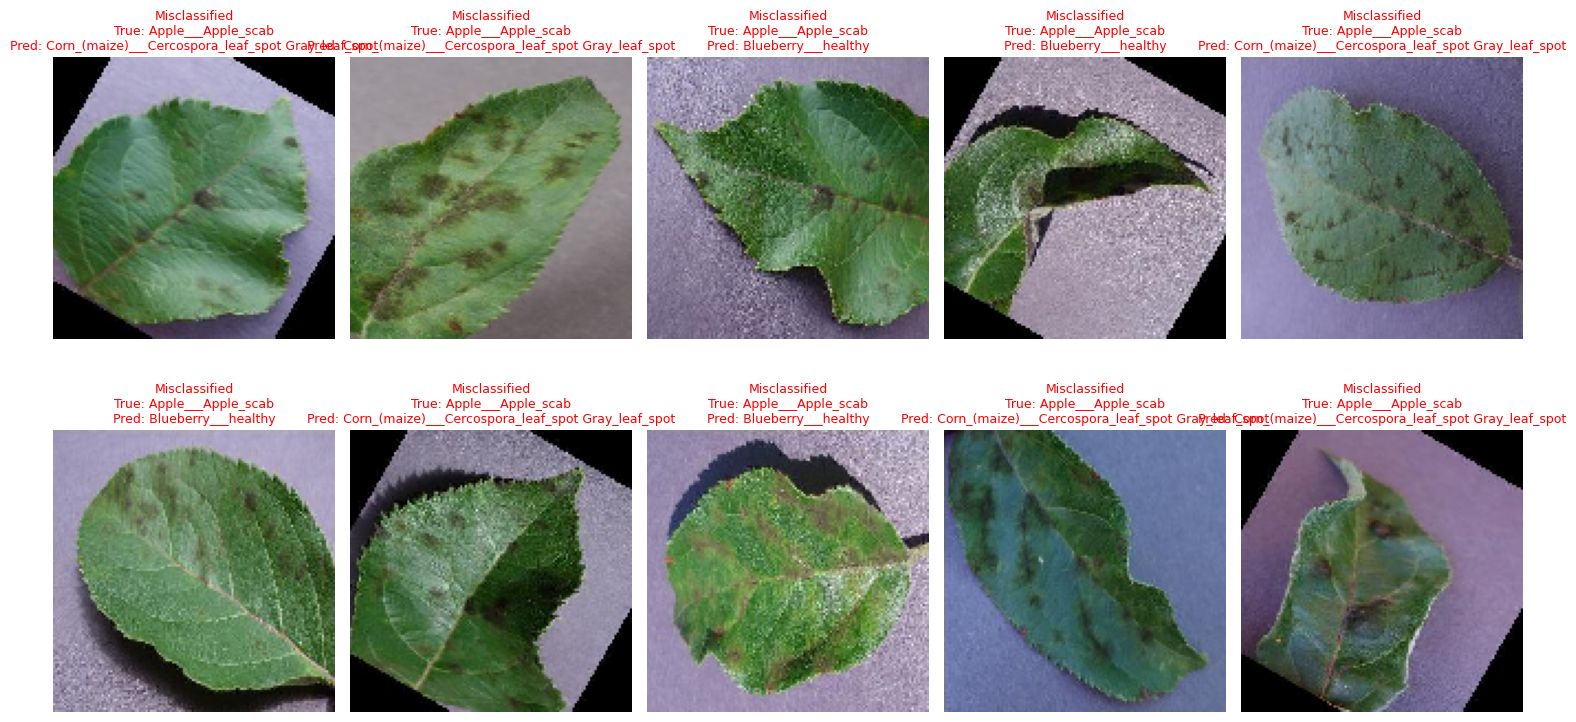

In [35]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

steps = ceil(test_generator.samples / test_generator.batch_size)
Y_pred_full = model.predict(test_generator, steps=steps, verbose=0)
if Y_pred_full.shape[0] > test_generator.samples:
    Y_pred_full = Y_pred_full[:test_generator.samples]
y_pred_full = np.argmax(Y_pred_full, axis=1)
y_true_full = np.array(test_generator.classes)[:len(y_pred_full)]
filepaths = np.array(test_generator.filepaths)[:len(y_pred_full)]

misclassified_idx = np.where(y_true_full != y_pred_full)[0]

if len(misclassified_idx) == 0:
    print("No misclassified images — showing 10 correctly predicted samples instead.")
    indices = np.where(y_true_full == y_pred_full)[0][:10]
    title_prefix = "Correct"
else:
    print(f"Total Misclassified Images: {len(misclassified_idx)} — displaying first 10.")
    indices = misclassified_idx[:10]
    title_prefix = "Misclassified"

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    fp = filepaths[idx]
    img = image.load_img(fp, target_size=IMAGE_SIZE)
    arr = image.img_to_array(img).astype('uint8') / 255.0
    plt.subplot(2, 5, i + 1)
    plt.imshow(arr)
    plt.title(f"{title_prefix}\nTrue: {class_labels[y_true_full[idx]]}\nPred: {class_labels[y_pred_full[idx]]}",
              color='red' if title_prefix == "Misclassified" else 'black', fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Step 13: **Save the Trained Model**

In [36]:
model.save('/content/drive/MyDrive/plant_disease_cnn_model.h5')
print("Model saved to Drive successfully!")


Model saved to Drive successfully!


# Step 14: **Test Prediction on a Single Image**

In [39]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Test image path
img_path = "/tmp/cnn_project/test/test/TomatoEarlyBlight4.JPG"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(pred)]

print("Predicted Disease:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Disease: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
